In [286]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [287]:
df = pd.read_csv('housing_price_data.csv')
df.head()

,House ID,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
0,0,Chicago,742.0,4,2,3,furnished,1330000
1,1,Denver,896.0,4,4,4,furnished,1225000
2,2,Chicago,996.0,3,2,2,semi-furnished,1225000
3,3,Seattle,750.0,4,2,2,furnished,1221500
4,4,New York,742.0,4,1,2,furnished,1141000


In [288]:
print(df.columns)

Index(['House ID', 'City', 'House Area (sqm)', 'No. of Bedrooms',
       'No. of Toilets', 'Stories', 'Renovation Status', 'Price ($)'],
      dtype='object')


In [289]:
#EDA (Exploratory Data Analysis)
print("Dataset shape:", df.shape)
print("\nData types and missing values:")
print(df.info())
print("\nSummary statistics for numerical columns:")
print(df.describe())

Dataset shape: (545, 8)

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   House ID           545 non-null    int64  
 1   City               545 non-null    object 
 2   House Area (sqm)   545 non-null    float64
 3   No. of Bedrooms    545 non-null    int64  
 4   No. of Toilets     545 non-null    int64  
 5   Stories            545 non-null    int64  
 6   Renovation Status  545 non-null    object 
 7   Price ($)          545 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 34.2+ KB
None

Summary statistics for numerical columns:
        House ID  House Area (sqm)  No. of Bedrooms  No. of Toilets  \
count  545.00000        545.000000       545.000000      545.000000   
mean   272.00000        515.054128         2.965138        1.286239   
std    157.47222        217.014102  

In [290]:
#check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())
df = df.drop(['House ID'], axis=1)


Missing values in each column:
House ID             0
City                 0
House Area (sqm)     0
No. of Bedrooms      0
No. of Toilets       0
Stories              0
Renovation Status    0
Price ($)            0
dtype: int64


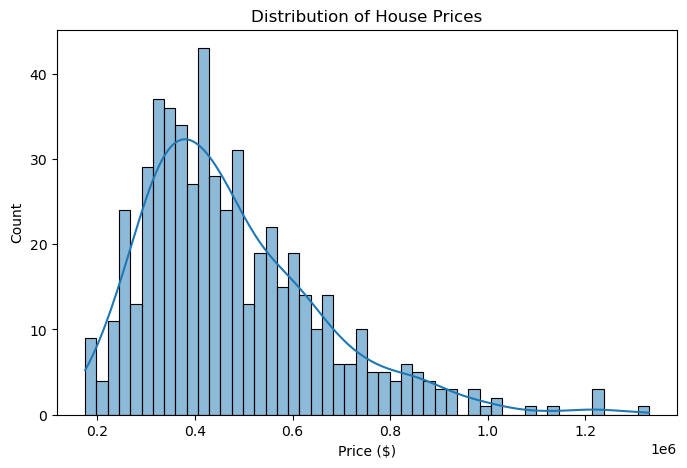

In [291]:
#distribution of target variable (price)
plt.figure(figsize=(8,5))
sns.histplot(df['Price ($)'], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

This Histogram shows the distribution of house prices. The Target Variable is skewed to the left when compared to the normal distribution.

In [292]:
from sklearn.preprocessing import StandardScaler

categorical_cols = ['City', 'Renovation Status']
numerical_cols = ['House Area (sqm)', 'No. of Bedrooms', 'No. of Toilets', 'Stories']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

df_encoded.head()

,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Price ($),City_Chicago,City_Denver,City_New York,City_Seattle,Renovation Status_semi-furnished,Renovation Status_unfurnished
0,1.046726,1.403419,1.421812,1.378217,1330000,True,False,False,False,False,False
1,1.757010,1.403419,5.405809,2.532024,1225000,False,True,False,False,False,False
2,2.218232,0.047278,1.421812,0.224410,1225000,True,False,False,False,True,False
3,1.083624,1.403419,1.421812,0.224410,1221500,False,False,False,True,False,False
4,1.046726,1.403419,-0.570187,0.224410,1141000,False,False,True,False,False,False


In [293]:
#train test split!!
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [294]:
#splitting features and target variables
X = df_encoded.drop('Price ($)', axis=1) #features
y = df_encoded['Price ($)'] #target variable

#split such that 20% of data goes into test data and 80% goes into train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [295]:
from sklearn.model_selection import cross_val_score
#LINEAR REGRESSION
from sklearn.linear_model import LinearRegression

#fit into model
model_lin = LinearRegression()
model_lin.fit(X_train, y_train)

#predict test datas
y_pred_lin = model_lin.predict(X_test)
scores_lin = cross_val_score(model_lin, X_train, y_train, cv=5, scoring='r2')
print("Linear Regression CV scores:", scores_lin)
print("Linear Regression Average R^2:", scores_lin.mean())


# Compare coefficients
print("Linear coefficients:", model_lin.coef_)

Linear Regression CV scores: [0.57366646 0.54376131 0.42216157 0.49447424 0.53848987]
Linear Regression Average R^2: 0.5145106911917146
Linear coefficients: [ 72087.470436    11449.30944289  61958.41822666  38914.3614819
  -7127.61951174   8745.65906436  10146.34208937    490.51216825
 -31681.81738282 -75818.51498292]


EVALUATION:

Linear Regression Model has an average R-squared value of 0.5145. This shows that the model explains about 51% of the variation in housing prices 

In [296]:
#evaluation of model
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Mean Squared Error (MSE):", mse_lin)
print("Root Mean Squared Error (RMSE):", rmse_lin)
print("R-squared (R2):", r2_lin)

Mean Squared Error (MSE): 24142884953.220955
Root Mean Squared Error (RMSE): 155379.80870505972
R-squared (R2): 0.5223553383077723


EVALUATION:

The Linear Regression Model has a RMSE value of 155379. This means that on average, the model’s housing price predictions are off by about $155,380 from the actual values.

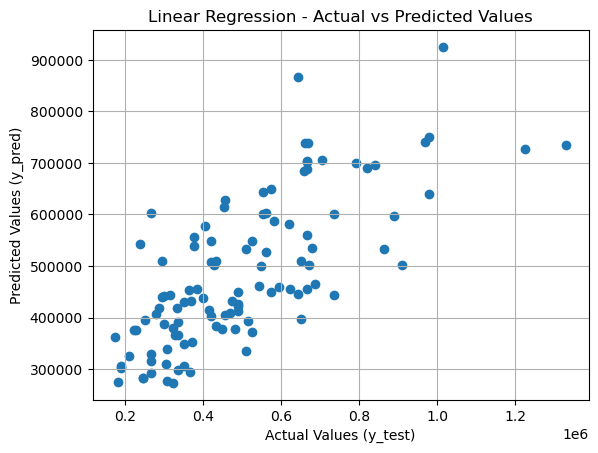

In [297]:
#predictions vs tests

plt.scatter(y_test, y_pred_lin)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Linear Regression - Actual vs Predicted Values")
plt.grid(True)
plt.show()

EVALUATION:

The Linear Regression Model did reasonably well as the points don't have much variance from line of perfect prediction

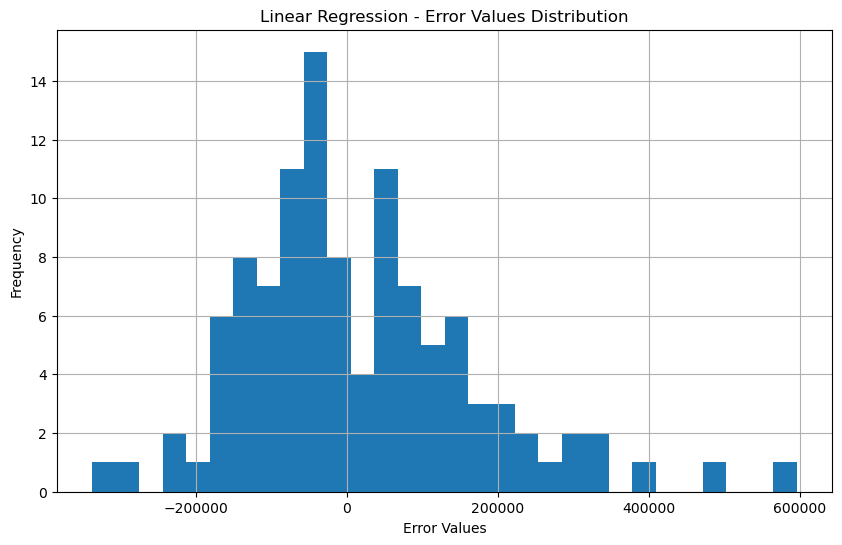

In [298]:
#predictions vs errors

error_lin = y_test - y_pred_lin

plt.figure(figsize=(10,6))
plt.hist(error_lin, bins=30)
plt.xlabel("Error Values")
plt.ylabel("Frequency")
plt.title("Linear Regression - Error Values Distribution")
plt.grid(True)
plt.show()

EVALUATION:

The error range for the linear regression model is approximately -180000 to 180000

In [299]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor

# fit into model
model_rf = RandomForestRegressor(n_estimators=100,random_state=42)
model_rf.fit(X_train, y_train)
scores_rf = cross_val_score(model_rf, X_train, y_train, cv=5)
print("Random Forest CV scores:", scores_rf)
print("Random Forest Average accuracy:", scores_rf.mean())
# predict test data
y_pred_rf = model_rf.predict(X_test)

Random Forest CV scores: [0.57509947 0.54183383 0.32278718 0.48524049 0.40854972]
Random Forest Average accuracy: 0.4667021352575646


EVALUATION:

Random Forest Model has an average accuracy value of 0.4667. This shows that the model is 46% accurate in predicting the values for x_test

In [300]:
#evaluation of model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Mean Squared Error (MSE):", mse_rf)
print("Root Mean Squared Error (RMSE):", rmse_rf)
print("R-squared (R2):", r2_rf)

Mean Squared Error (MSE): 27076771594.138046
Root Mean Squared Error (RMSE): 164550.2099486295
R-squared (R2): 0.46431110313209034


EVALUATION:

The Random Forest Model has a RMSE value of 164550. This means that on average, the model’s housing price predictions are off by about $164,550 from the actual values.

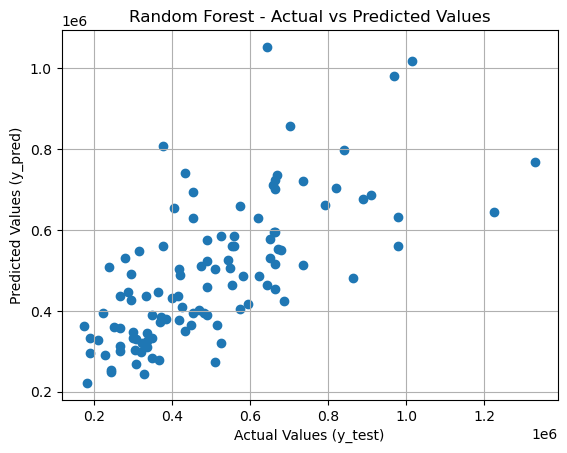

In [301]:
#predictions vs tests

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Random Forest - Actual vs Predicted Values")
plt.grid(True)
plt.show()

EVALUATION:

The Random Forest Model did reasonably well as the points don't have much variance from line of perfect prediction

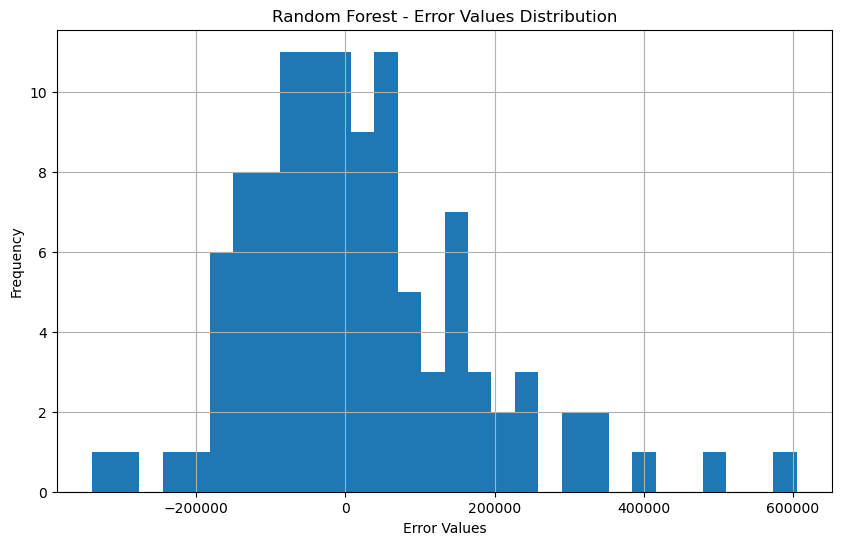

In [302]:
#predictions vs errors

error_rf = y_test - y_pred_rf

plt.figure(figsize=(10,6))
plt.hist(error, bins=30)
plt.xlabel("Error Values")
plt.ylabel("Frequency")
plt.title("Random Forest - Error Values Distribution")
plt.grid(True)
plt.show()

EVALUATION:

The error range for the linear regression model is approximately -190000 to 150000

In [303]:
# RIDGE REGRESSION
from sklearn.linear_model import Ridge

model_rid = Ridge(alpha=1.0)
model_rid.fit(X_train, y_train)
scores_rid = cross_val_score(model_rid, X_train, y_train, cv=5, scoring='r2')
print("Ridge CV scores:", scores_rid)
print("Ridge Average R^2:", scores_rid.mean())

y_pred_rid = model_rid.predict(X_test)

Ridge CV scores: [0.57415739 0.54339926 0.42623354 0.49418365 0.53897784]
Ridge Average R^2: 0.5153903339053418


EVALUATION:

Ridge Regression Model has an average accuracy value of 0.5154. This shows that the model is 52% accurate in predicting the values for x_test

In [304]:
#evaluation of model
mse_rid = mean_squared_error(y_test, y_pred_rid)
rmse_rid = np.sqrt(mse_rid)
r2_rid = r2_score(y_test, y_pred_rid)

print("Mean Squared Error (MSE):", mse_rid)
print("Root Mean Squared Error (RMSE):", rmse_rid)
print("R-squared (R2):", r2_rid)

Mean Squared Error (MSE): 24139548216.0852
Root Mean Squared Error (RMSE): 155369.07097645014
R-squared (R2): 0.5224213525676029


EVALUATION:

The Ridge Regression Model has a RMSE value of 155369. This means that on average, the model’s housing price predictions are off by about $155,369 from the actual values.

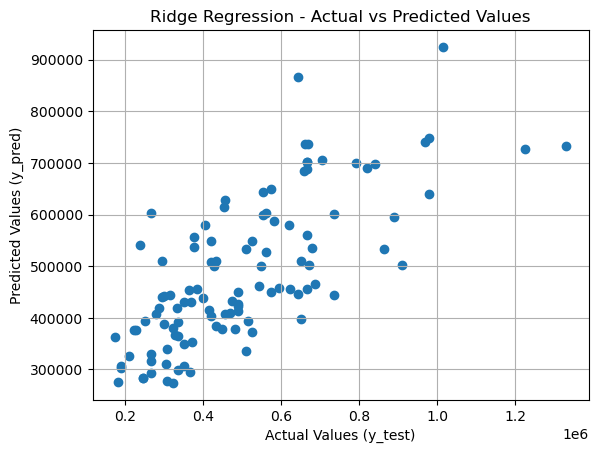

In [305]:
#predictions vs tests

plt.scatter(y_test, y_pred_rid)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Ridge Regression - Actual vs Predicted Values")
plt.grid(True)
plt.show()

EVALUATION:

The Ridge Regression Model did reasonably well as the points don't have much variance from line of perfect prediction

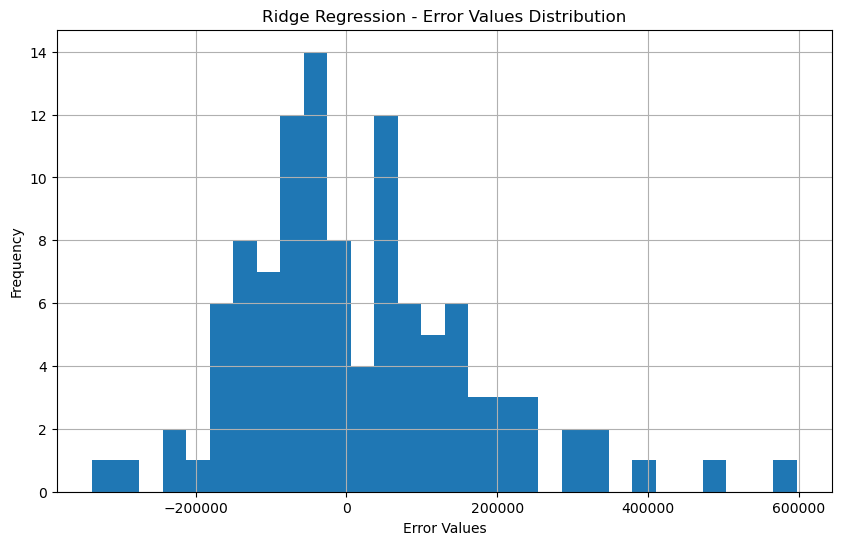

In [306]:
#predictions vs errors

error_rid = y_test - y_pred_rid

plt.figure(figsize=(10,6))
plt.hist(error_rid, bins=30)
plt.xlabel("Error Values")
plt.ylabel("Frequency")
plt.title("Ridge Regression - Error Values Distribution")
plt.grid(True)
plt.show()

EVALUATION:

The error range for the ridge regression model is approximately -190000 to 160000

In [307]:
#cross validation
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)
print(f"Best alpha: {lasso_cv.alpha_}")

Best alpha: 2199.0284859354297


In [308]:
# LASSO REGRESSION
from sklearn.linear_model import Lasso

model_las = Lasso(alpha=100)  
model_las.fit(X_train, y_train)
scores_las = cross_val_score(model_las, X_train, y_train, cv=5, scoring='r2')
print("Lasso CV scores:", scores_las)
print("Lasso Average R^2:", scores_las.mean())

y_pred_las = model_las.predict(X_test)
# Compare coefficients
print("Lasso coefficients:", model_las.coef_)

Lasso CV scores: [0.57469689 0.54387397 0.42475603 0.49455342 0.5393491 ]
Lasso Average R^2: 0.5154458830431422
Lasso coefficients: [ 72099.0125845   11457.88326523  61848.05464577  38904.55284732
  -6748.47749523   7592.96950803   9313.95119609     -0.
 -30696.80533593 -74840.21598918]


EVALUATION:

Lasso Regression Model has an average R-squared value of 0.5144. This shows that the model explains about 51% of the variation in housing prices 

In [309]:
#evaluation of model
mse_las = mean_squared_error(y_test, y_pred_las)
rmse_las = np.sqrt(mse_las)
r2_las = r2_score(y_test, y_pred_las)

print("Mean Squared Error (MSE):", mse_las)
print("Root Mean Squared Error (RMSE):", rmse_las)
print("R-squared (R2):", r2_las)

Mean Squared Error (MSE): 24104801797.149986
Root Mean Squared Error (RMSE): 155257.2117395839
R-squared (R2): 0.5231087783474748


EVALUATION:

The Ridge Regression Model has a RMSE value of 155257. This means that on average, the model’s housing price predictions are off by about $155,257 from the actual values.

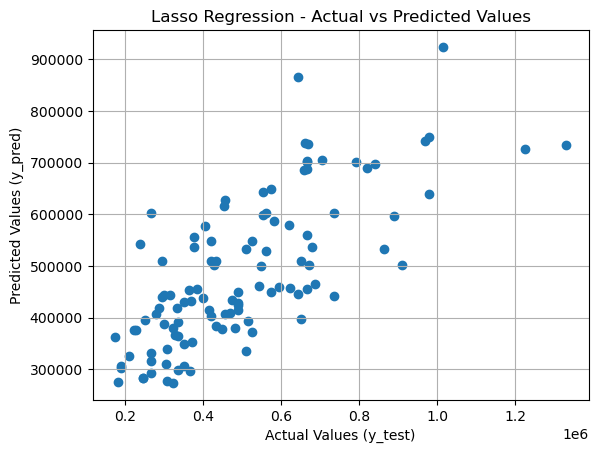

In [310]:
#predictions vs tests

plt.scatter(y_test, y_pred_las)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Lasso Regression - Actual vs Predicted Values")
plt.grid(True)
plt.show()

EVALUATION:

The Lasso Regression Model did very well as the points don't have much variance from line of perfect prediction

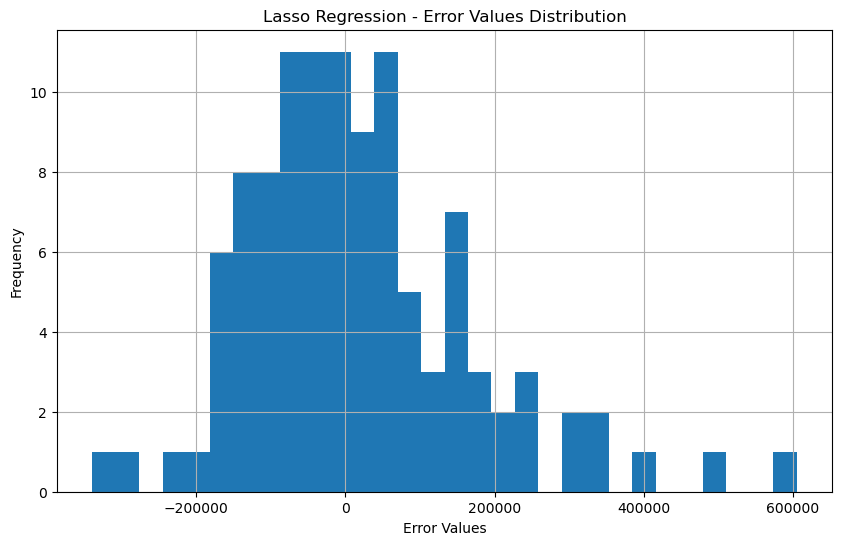

In [311]:
#predictions vs errors

error = y_test - y_pred

plt.figure(figsize=(10,6)) 
plt.hist(error, bins=30)
plt.xlabel("Error Values")
plt.ylabel("Frequency")
plt.title("Lasso Regression - Error Values Distribution")
plt.grid(True)
plt.show()

EVALUATION:

The error range for the linear regression model is approximately -190000 to 130000

In [312]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

mse_dummy = mean_squared_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mse_dummy)
r2_dummy = r2_score(y_test, y_pred_dummy)

print("DUMMY BASELINE RESULTS:")
print("MSE:", mse_dummy)
print("RMSE:", rmse_dummy)
print("R²:", r2_dummy)

DUMMY BASELINE RESULTS:
MSE: 51451768522.26261
RMSE: 226829.82282376938
R²: -0.0179256794248297


EVALUATION:

The Dummy Model has a RMSE value of 226829. This means that on average, the model’s housing price predictions are off by about $226,829 from the actual values.

In [313]:
#models
models = ["Linear", "Lasso", "Ridge", "Random Forest", "Dummy"]

#rmse
rmse_values = [rmse_lin, rmse_las, rmse_rid, rmse_rf, rmse_dummy]

#mse
mse_values = [mse_lin, mse_las, mse_rid, mse_rf, mse_dummy]

#R squared scores
r2_values = [r2_lin, r2_las, r2_rid, r2_rf, r2_dummy]

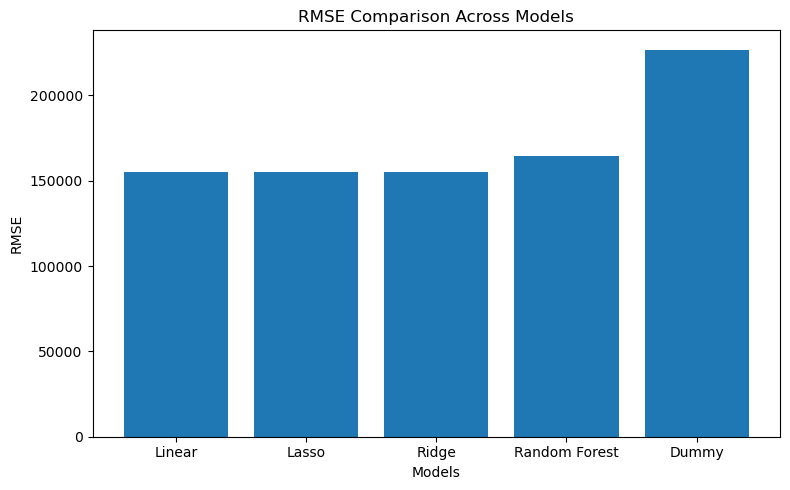

In [314]:
#RMSE plots
plt.figure(figsize=(8,5))
plt.bar(models, rmse_values)
plt.title("RMSE Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

This Bar Chart Shows that the RMSE value for the dummy model is the highest whereas the rest are lower. Since the lower the RMSE value, the better the model is, the bar chart shows that the best models are linear regression, lasso regression and ridge regression.

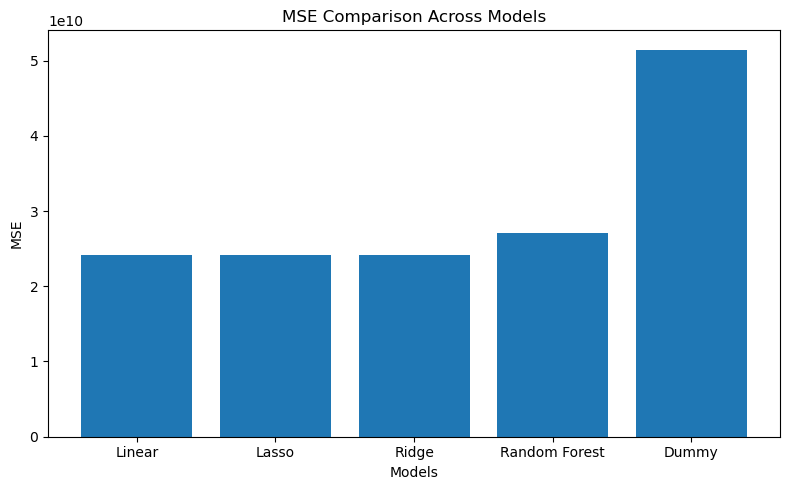

In [315]:
#MSE plot
plt.figure(figsize=(8,5))
plt.bar(models, mse_values)
plt.title("MSE Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

This Bar Chart Shows that the MSE value for the dummy model is the highest whereas the rest are lower. Since the lower the MSE value, the better the model is, the bar chart shows that the best models are linear regression, lasso regression and ridge regression.

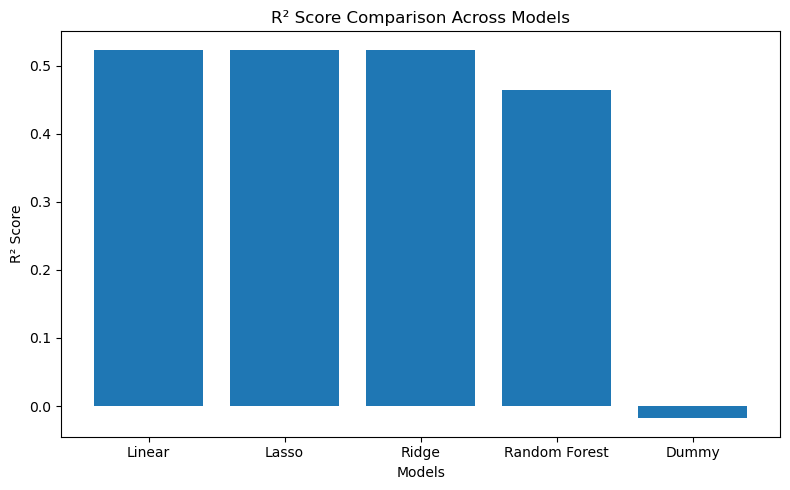

In [316]:
# R² Bar Chart
plt.figure(figsize=(8,5))
plt.bar(models, r2_values)
plt.title("R² Score Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.tight_layout()
plt.show()

This Bar Chart Shows that the Rsquared value for the dummy model is the highest whereas the rest are lower. Since the higher the Rsquared value, the better the model is, the bar chart shows that the best models are linear regression, lasso regression and ridge regression.

Lasso Regression is selected as final model due to automatic feature selection (sets irrelevant coefficients to zero) & simplicity

In [317]:
print(r2_values)
print(rmse_values)
print(mse_values)

[0.5223553383077723, 0.5231087783474748, 0.5224213525676029, 0.46431110313209034, -0.0179256794248297]
[np.float64(155379.80870505972), np.float64(155257.2117395839), np.float64(155369.07097645014), np.float64(164550.2099486295), np.float64(226829.82282376938)]
[24142884953.220955, 24104801797.149986, 24139548216.0852, 27076771594.138046, 51451768522.26261]


In [318]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Lasso
param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]  # common values for regularization strength
}

# Set up GridSearchCV
grid_search_lasso = GridSearchCV(
    Lasso(random_state=42),
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',  # using MSE for regression
    n_jobs=-1
)

# Fit on training data
grid_search_lasso.fit(X_train, y_train)

# Best parameters and CV score
print("Best alpha:", grid_search_lasso.best_params_['alpha'])
print("Best CV MSE:", -grid_search_lasso.best_score_)

# Use the best Lasso model
best_lasso = grid_search_lasso.best_estimator_

Best alpha: 100
Best CV MSE: 14426081352.57259


EVALUATION:

The Best Alpha to use for Lasso Regression is 100. 

                            Feature   Coefficient  Abs_Coefficient
9     Renovation Status_unfurnished -74840.215989     74840.215989
0                  House Area (sqm)  72099.012584     72099.012584
2                    No. of Toilets  61848.054646     61848.054646
3                           Stories  38904.552847     38904.552847
8  Renovation Status_semi-furnished -30696.805336     30696.805336
1                   No. of Bedrooms  11457.883265     11457.883265
6                     City_New York   9313.951196      9313.951196
5                       City_Denver   7592.969508      7592.969508
4                      City_Chicago  -6748.477495      6748.477495
7                      City_Seattle     -0.000000         0.000000


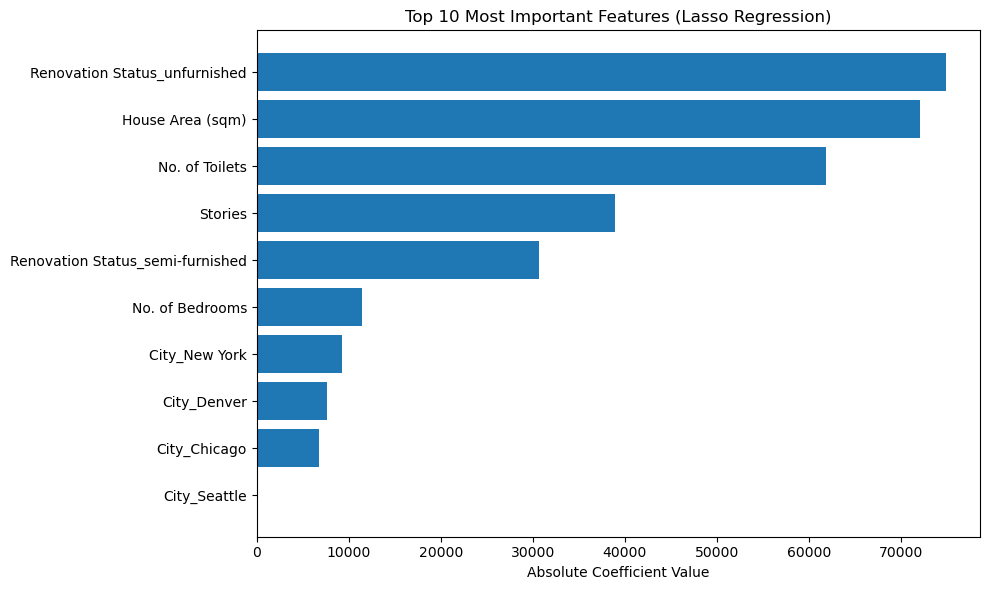

In [319]:
lasso_model = best_lasso
lasso_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso_model.coef_
})

coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
print(coef_df)
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'].head(10), coef_df['Abs_Coefficient'].head(10))
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 10 Most Important Features (Lasso Regression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This barchart shows that Renovation Status is the most important feature that influences the House Pricing (target variable), then followed by House Area & No. of Toilets.

City_Seattle has zero coefficient therefore it has no influence on the housing price.